
<div dir="ltr" align="center">

  <span style="font-size: 60px; color: #0B3C78; font-weight: 700;">
    Artificial Intelligence
  </span><br><br>

  <span style="font-size: 22px; color: #1F5FA8; font-weight: 500;">
    Computer Engineering Department
  </span><br>

  <span style="font-size: 20px; color: #1F5FA8; font-weight: 500;">
    Sharif University of Technology
  </span><br><br>

  <span style="font-size: 22px; color: #1F7A8C; font-weight: 600;">
    Spring 2026
  </span><br><br>

  <span style="font-size: 24px; color: #145DA0; font-weight: 700;">
    Practical Assignment
  </span><br><br>

  <span style="font-size: 22px; color: #3A7CC2; font-weight: 600;">
    N-Queens
  </span><br><br><br>

</div>

---

- Instructor: Dr.Tanghatari
- Practical Designer: Iliya Forsati

---

### Student Information

- Name: Arvin
- Last Name: Baghal Asl
- Student Number: 403105793

---

### Instructions

- Make sure to:
  - Fill in your personal information above.
  - Run all the cells in the notebook and make sure your code runs truly 


# N-Queens Problem

The N-Queens problem asks us to place N queens on an N×N chessboard so that no two queens attack each other.

We represent the board as a list where `board[col] = row` shows the queen's position in each column.

We will solve this using local search methods:

- Hill Climbing
- Hill Climbing with Sideways Moves
- Min-Conflicts
- Simulated Annealing
- Beam Search

The goal is to reach zero conflicts.

## 1- import libraries

In [2]:
import random
import math
import time
from typing import List, Optional, Tuple
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from IPython.display import HTML

## 2- Implement `NQueensState` class (10 points)

This class models the chessboard and provides the core methods needed for our search algorithms.

In [3]:
class NQueensState:
	"""
	Models the N-Queens chessboard.
	board[col] = row means the queen in column 'col' is placed at row 'row'.
	"""
	def __init__(self, n: int, board: Optional[List[int]] = None):
		self.n = n
		# random assignment if board is none
		if board is None:
			self.board = [random.randrange(n) for _ in range(n)]
		else:
			self.board = board[:]

	def copy(self):
		return NQueensState(self.n, self.board[:])

	def get_board(self) -> List[int]:
		return self.board[:]

	def set_queen_position(self, col: int, row: int):
		self.board[col] = row

	def calculate_conflicts(self) -> int:
		conflicts = 0
		for i in range(self.n):
			for j in range(i + 1, self.n):
				if self.board[i] == self.board[j]:
					conflicts += 1
				elif abs(self.board[i] - self.board[j]) == abs(i - j):
					conflicts += 1
		return conflicts

	def is_goal(self) -> bool:
		return self.calculate_conflicts() == 0

	def generate_neighbors(self) -> List['NQueensState']:
		neighbors = []
		for col in range(self.n):
			for row in range(self.n):
				if self.board[col] == row:
					continue
				new_state = self.copy()
				new_state.set_queen_position(col, row)
				neighbors.append(new_state)
		
		return neighbors

## 3- Implement visualization methods

These methods help us see the board and watch the solution path as an animation.

In [4]:
def visualize_board(state: NQueensState):
    n = state.n
    board = state.get_board()
    
    ـ, ax = plt.subplots(figsize=(8, 8))
    
    for row in range(n):
        for col in range(n):
            color = '#F0D9B5' if (row + col) % 2 == 0 else '#B58863'
            rect = patches.Rectangle((col, n - 1 - row), 1, 1, 
                                     linewidth=1, edgecolor='black', 
                                     facecolor=color)
            ax.add_patch(rect)
    
    for col in range(n):
        row = board[col]
        ax.text(col + 0.5, n - 1 - row + 0.5, '♛', 
                fontsize=400 // n, ha='center', va='center', 
                color='black')
    
    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    ax.set_title(f'{n}-Queens  |  Conflicts: {state.calculate_conflicts()}', 
                 fontsize=16, pad=20)
    
    plt.tight_layout()
    plt.show()

In [5]:
def show_solution_animation(state_sequence: List[NQueensState], interval: int = 500):
    n = state_sequence[0].n
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    def draw_frame(state):
        ax.clear()
        board = state.get_board()
        
        for row in range(n):
            for col in range(n):
                color = '#F0D9B5' if (row + col) % 2 == 0 else '#B58863'
                rect = patches.Rectangle((col, n - 1 - row), 1, 1,
                                         linewidth=1, edgecolor='black',
                                         facecolor=color)
                ax.add_patch(rect)
        
        for col in range(n):
            row = board[col]
            ax.text(col + 0.5, n - 1 - row + 0.5, '♛',
                    fontsize=400 // n, ha='center', va='center',
                    color='black')
        
        ax.set_xlim(0, n)
        ax.set_ylim(0, n)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')
        ax.set_title(f'{n}-Queens  |  Conflicts: {state.calculate_conflicts()}',
                     fontsize=16, pad=20)
    
    anim = animation.FuncAnimation(fig, draw_frame, frames=state_sequence,
                                   interval=interval, repeat=True, repeat_delay=2000)
    
    plt.close()
    return HTML(anim.to_jshtml())

Now you have to implement some ***Local Search*** methods and find the probability of success and time execution of each one. Then compare them together.

## 4- Hill Climbing

### 4.1.1- Simple Hill Climbing (10 points)

Hill Climbing always moves to the best neighbor. It stops when no neighbor is better than the current state.

Initial state conflicts: 12
Final state conflicts: 2
Is solution? False
Path length: 4
initial state:


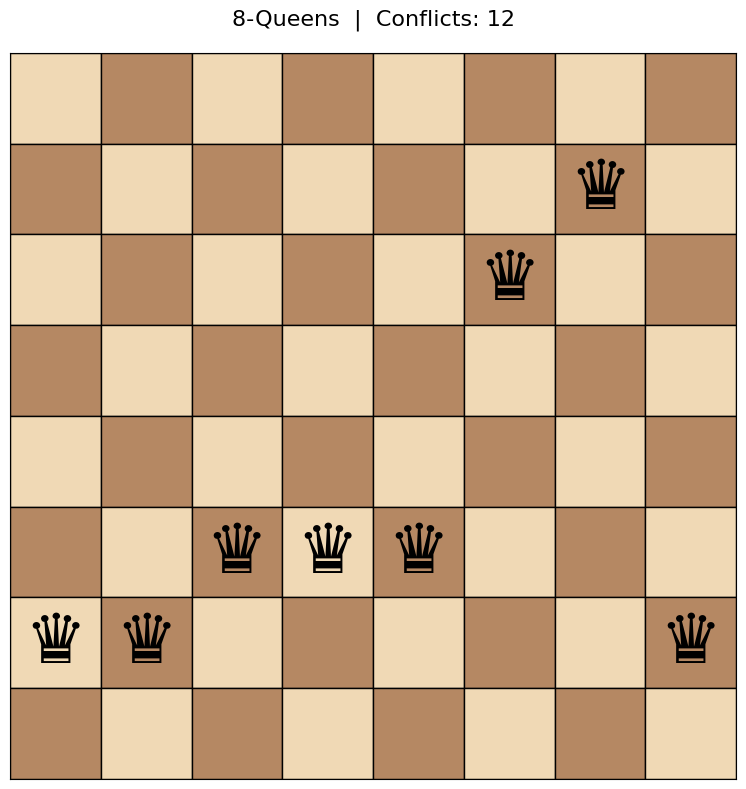

final state:


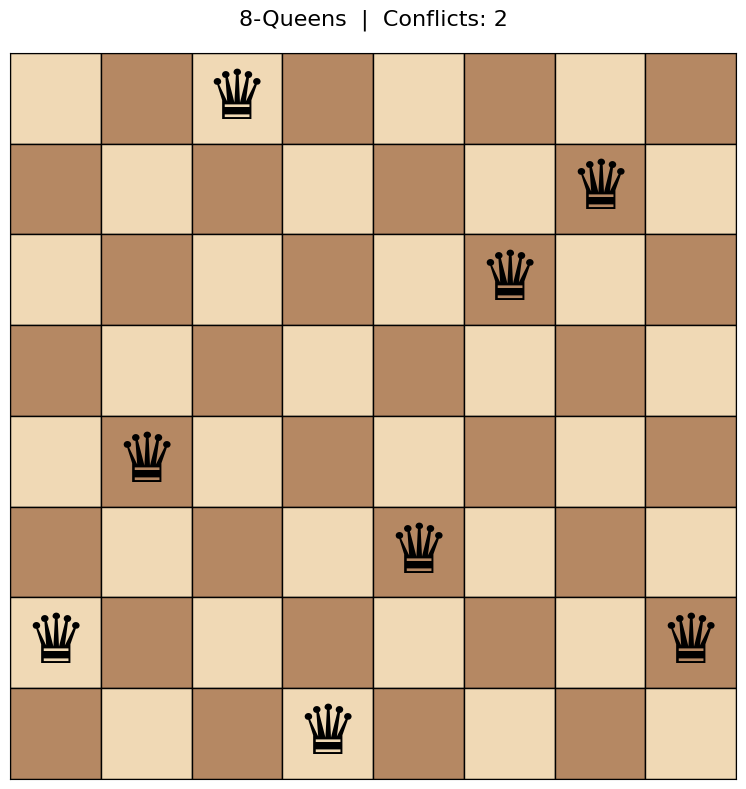

solution:


In [6]:
def hill_climbing(initial_state: NQueensState, max_iterations: int = 1000) -> Tuple[NQueensState, List[NQueensState]]:
	"""
	Simple Hill Climbing algorithm.
	Starts from an initial state and always moves to the best neighbor.
	Stops when no better neighbor exists or goal is reached.
	Returns the final state and the path of states visited.
	"""
	# create a copy of the initial state and a path list
	current = initial_state.copy()
	path = [current]
	# loop until max_iterations
		# if current is goal, break
		# generate neighbors and find the one with lowest conflicts
		# if no better neighbor, break
		# move to best neighbor and add to path
	for _ in range(max_iterations):
		if current.is_goal():
			break
		
		min_conflicts = current.calculate_conflicts()
		best_neighbor = None

		for neighbor in current.generate_neighbors():
			neighbor_conflicts = neighbor.calculate_conflicts()
			if neighbor_conflicts < min_conflicts:
				best_neighbor = neighbor
				min_conflicts = neighbor_conflicts
		
		if best_neighbor is None:
			break

		current = best_neighbor
		path.append(current)
		
	# return final state and path
	return current, path


# Test and visualize
n = 8
initial = NQueensState(n)
solution, path = hill_climbing(initial)

print(f"Initial state conflicts: {path[0].calculate_conflicts()}")
print(f"Final state conflicts: {solution.calculate_conflicts()}")
print(f"Is solution? {solution.is_goal()}")
print(f"Path length: {len(path)}")

# Show initial state
print("initial state:")
visualize_board(path[0])

# Show final state
print("final state:")
visualize_board(solution)

# Show the animation
print("solution:")
show_solution_animation(path)

### 4.1.2- Simple HC success probability (5 points)

We use ***Monte Carlo*** simulation to estimate the probability of success. 
- Find the probability for 8 queens.
- Find the probability for 16 queens.
- Find the mean execution time for each.
- Find the mean path length.

In [7]:
def evaluate_hc(n: int, trials: int = 1000, max_iterations: int = 1000) -> tuple:
    """
    Evaluate Hill Climbing using Monte Carlo simulation.
    Runs the algorithm multiple times and returns:
    - success rate
    - mean execution time
    - mean path length
    """
    # initialize counters for successes, total_time, total_path_length
    successes = 0
    total_time = 0.0
    total_path_length = 0
    # loop for the number of trials
        # create a random initial state
        # measure time and run hill climbing
        # update counters
    for _ in range(trials):
        initial_state = NQueensState(n)
        start_time = time.time()
        solution, path = hill_climbing(initial_state, max_iterations)
        end_time = time.time()
        if solution.is_goal():
            successes += 1
        total_time += end_time - start_time
        total_path_length += len(path)
    # calculate and return averages
    return successes/trials, total_time/trials, total_path_length/trials


prob_8, time_8, path_8 = evaluate_hc(8)
print(f"8 Queens  -> Success: {prob_8:.2%}, Mean Time: {time_8*1000:.6f}ms, Mean Path: {path_8:.1f}")

prob_16, time_16, path_16 = evaluate_hc(16)
print(f"16 Queens -> Success: {prob_16:.2%}, Mean Time: {time_16*1000:.6f}ms, Mean Path: {path_16:.1f}")

8 Queens  -> Success: 17.00%, Mean Time: 1.133009ms, Mean Path: 4.3
16 Queens -> Success: 3.30%, Mean Time: 29.648728ms, Mean Path: 7.7


#### Explain the results. (5 points)

Simple hill climbing solves the 8‑queens problem about 17% of the time, averaging only 4.3 moves and about 1.1 ms. For 16‑queens, the success rate drops sharply to 3.3%. The average path length grows just a bit to 7.7 moves, but the running time jumps to nearly 30 ms. Why? A larger board means a much bigger search space packed with more local optima, so the algorithm gets stuck more often before finding a solution. The extra time comes from the fact that each move requires checking O(n²) queen pairs, so doubling the board size roughly quadruples the work per step. Bottom line: simple hill climbing works fine on small problems, but quickly loses reliability as n grows—which is exactly why we turn to smarter strategies like sideways moves or simulated annealing.

### 4.2.1- Hill Climbing with sideways move (10 points)

Initial state conflicts: 6
Final state conflicts: 0
Is solution? True
Path length: 10
initial state:


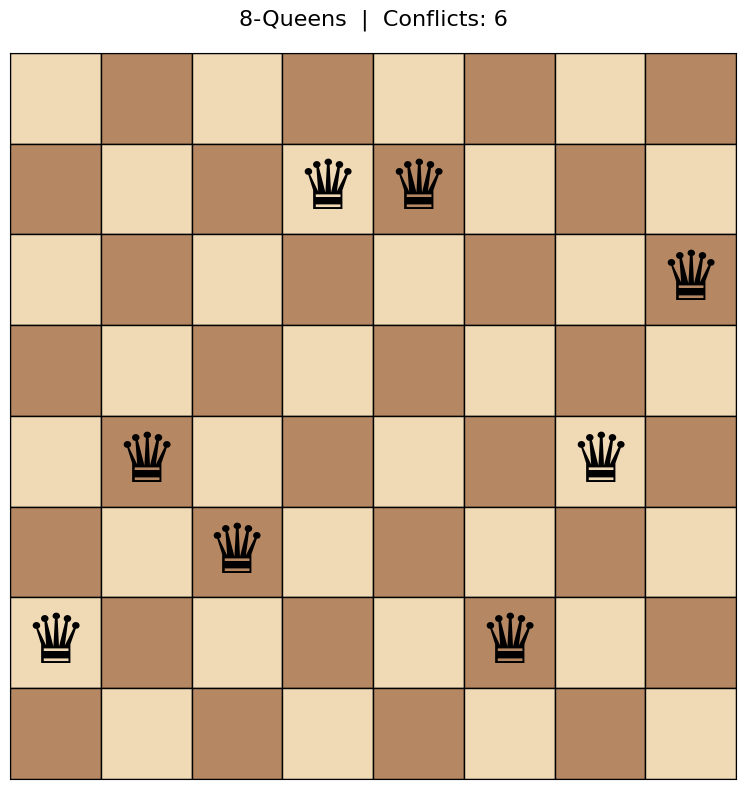

final state:


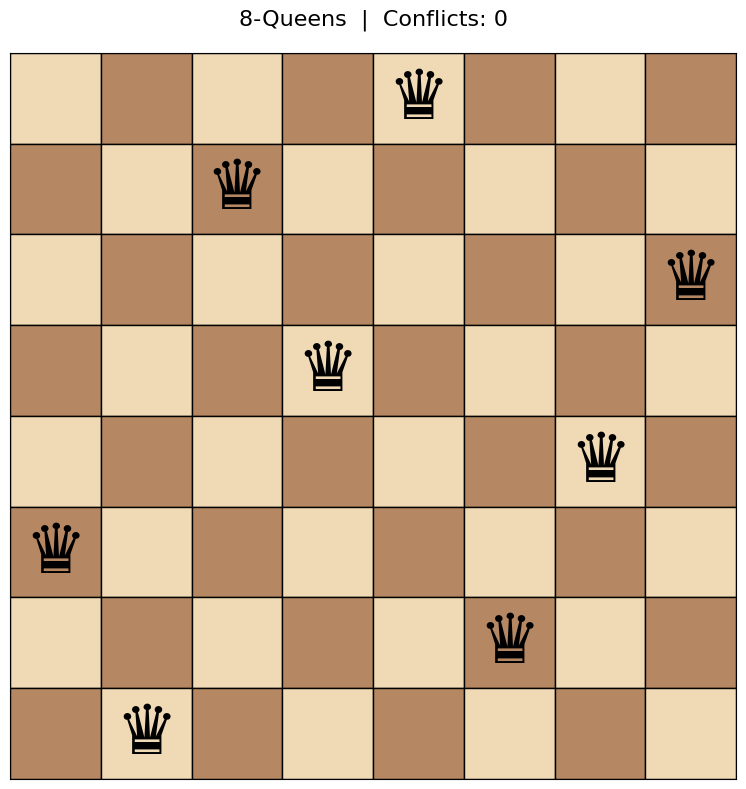

solution:


In [8]:
def hill_climbing_with_sideways_move(initial_state: NQueensState, max_iterations: int = 1000, max_sideways: int = 100) -> Tuple[NQueensState, List[NQueensState]]:
	"""
	Hill Climbing with sideways moves.
	Like simple HC but allows moves to neighbors with equal conflicts.
	Stops after max_sideways consecutive sideways moves.
	"""
	# create a copy of the initial state and a path list, set sideways_count to 0
	current = initial_state.copy()
	path = [current]
	sideways_count = 0
	# loop until max_iterations
		# if current is goal, break
		# generate neighbors, find best neighbor and collect sideways neighbors
		# if best neighbor is worse than current, break
		# if best neighbor has equal conflicts, increment sideways_count
			# if sideways_count exceeds max_sideways, break
			# choose a random sideways neighbor
		# otherwise, reset sideways_count
		# move to best neighbor and add to path
	for _ in range(max_iterations):
		if current.is_goal():
			break
		
		current_conflicts = current.calculate_conflicts()
		min_conflicts = current_conflicts + 1
		best_neighbor = None
		sideways_neighbors = []

		for neighbor in current.generate_neighbors():
			neighbor_conflicts = neighbor.calculate_conflicts()
			if neighbor_conflicts < min_conflicts:
				best_neighbor = neighbor
				min_conflicts = neighbor_conflicts
			if neighbor_conflicts == current_conflicts:
				sideways_neighbors.append(neighbor)
		
		if min_conflicts > current_conflicts:
			break
		elif min_conflicts == current_conflicts:
			sideways_count += 1
			if sideways_count > max_sideways:
				break
			best_neighbor = sideways_neighbors[random.randint(0, len(sideways_neighbors) - 1)]
		else:
			sideways_count = 0

		current = best_neighbor
		path.append(current)
	# return final state and path
	return current, path


# Test and visualize
n = 8
initial = NQueensState(n)
solution, path = hill_climbing_with_sideways_move(initial)

print(f"Initial state conflicts: {path[0].calculate_conflicts()}")
print(f"Final state conflicts: {solution.calculate_conflicts()}")
print(f"Is solution? {solution.is_goal()}")
print(f"Path length: {len(path)}")

# Show initial state
print("initial state:")
visualize_board(path[0])

# Show final state
print("final state:")
visualize_board(solution)

# Show the animation
print("solution:")
show_solution_animation(path)

### 4.1.2- HC with sideways move success probability (5 points)
Use different amounts of ***max_iterations*** (for example 500, 50) and explain your result at the end.

- Find the probability for 8 queens.
- Find the probability for 16 queens.
- Find the mean execution time for each.
- Find the mean path length.

In [9]:
def evaluate_hc_with_sideways(n: int, trials: int = 1000, max_iterations: int = 500) -> tuple:
    """
    Evaluate Hill Climbing with sideways moves using Monte Carlo simulation.
    Returns success rate, mean execution time, and mean path length.
    """
    # initialize counters for successes, total_time, total_path_length
    successes = 0
    total_time = 0.0
    total_path_length = 0
    # loop for the number of trials
        # create a random initial state
        # measure time and run hill climbing with sideways moves
        # update counters
    for _ in range(trials):
        initial_state = NQueensState(n)
        start_time = time.time()
        solution, path = hill_climbing_with_sideways_move(initial_state, max_iterations)
        end_time = time.time()
        if solution.is_goal():
            successes += 1
        total_time += end_time - start_time
        total_path_length += len(path)
    # calculate and return averages
    return successes/trials, total_time/trials, total_path_length/trials

# max iterations = 500
print("max iterations = 500")
prob_8, time_8, path_8 = evaluate_hc_with_sideways(8, max_iterations=500)
print(f"8 Queens  -> Success: {prob_8:.2%}, Mean Time: {time_8*1000:.6f}ms, Mean Path: {path_8:.1f}")

prob_16, time_16, path_16 = evaluate_hc_with_sideways(16, max_iterations=500)
print(f"16 Queens -> Success: {prob_16:.2%}, Mean Time: {time_16*1000:.6f}ms, Mean Path: {path_16:.1f}")

# max iterations = 50
print("max iterations = 50")
prob_8, time_8, path_8 = evaluate_hc_with_sideways(8, max_iterations=50)
print(f"8 Queens  -> Success: {prob_8:.2%}, Mean Time: {time_8*1000:.6f}ms, Mean Path: {path_8:.1f}")

prob_16, time_16, path_16 = evaluate_hc_with_sideways(16, max_iterations=50)
print(f"16 Queens -> Success: {prob_16:.2%}, Mean Time: {time_16*1000:.6f}ms, Mean Path: {path_16:.1f}")

max iterations = 500
8 Queens  -> Success: 95.20%, Mean Time: 5.012448ms, Mean Path: 21.8
16 Queens -> Success: 97.80%, Mean Time: 109.937102ms, Mean Path: 33.2
max iterations = 50
8 Queens  -> Success: 85.70%, Mean Time: 4.371334ms, Mean Path: 19.8
16 Queens -> Success: 83.10%, Mean Time: 94.272135ms, Mean Path: 28.4


### Explain you results. (5 points)

Adding sideways moves completely changes the game. Simple HC succeeded only 17% of the time on 8‑queens and 3% on 16‑queens. With sideways moves, even just 50 of them, success jumps to 86% and 83%. Give it 500 moves and you get 95% on 8‑queens and 98% on 16‑queens—the larger board actually does slightly better because it has more flat plateaus to explore. The catch is time: 16‑queens takes 110 ms with 500 moves versus just 30 ms for simple HC. So sideways moves work great for reliability, but you pay for it with longer runs.

### 5.1- Simulated Annealing (10 points)

Initial conflicts: 10
Final conflicts: 1
Is solution? False
Steps: 29
initial state:


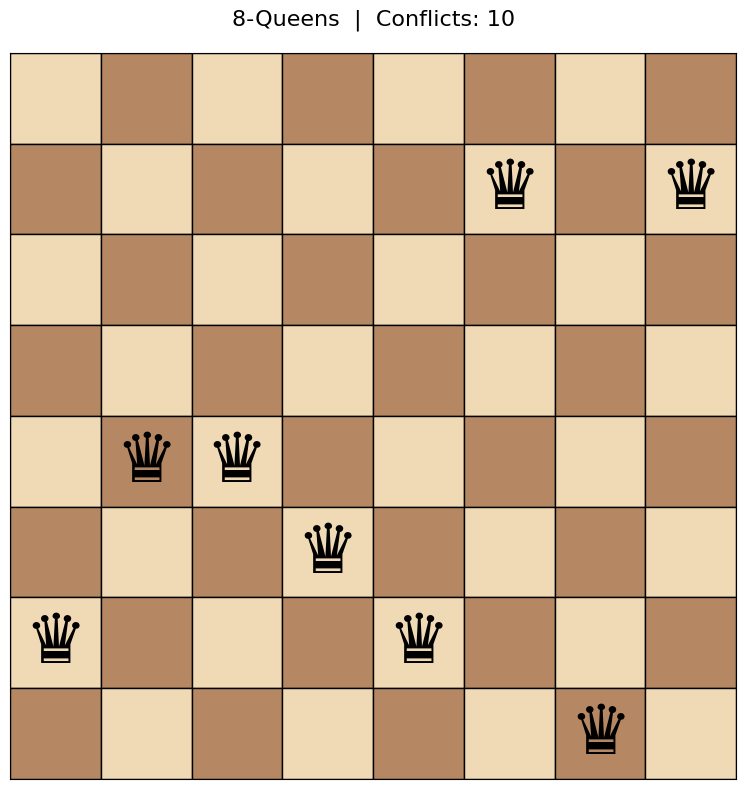

final state:


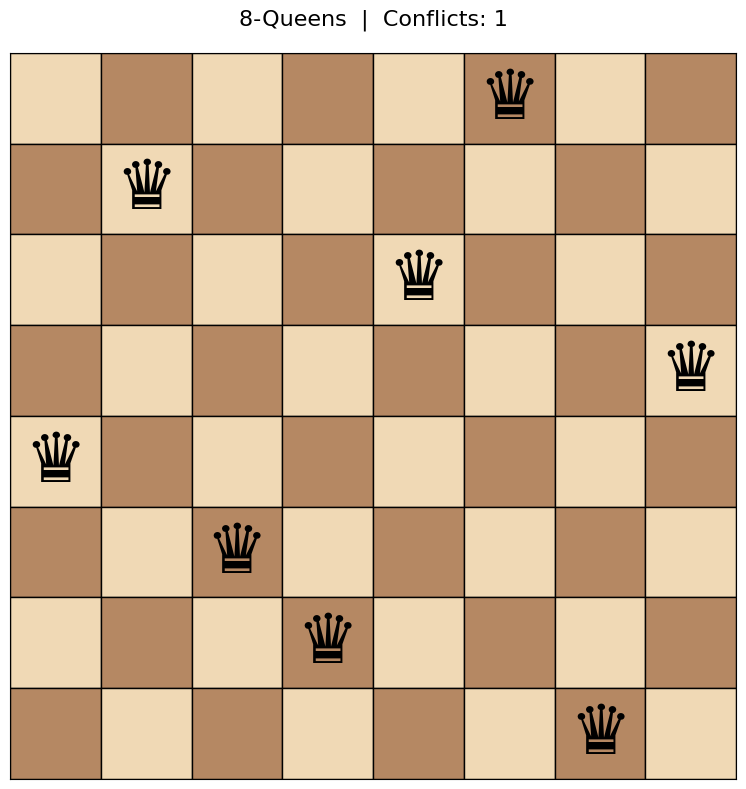

solution:


In [10]:
def simulated_annealing(initial_state: NQueensState, initial_temp: float = 1.0, cooling_rate: float = 0.9, max_iterations: int = 10000) -> Tuple[NQueensState, List[NQueensState]]:
	"""
	Simulated Annealing algorithm.
	Randomly moves a queen and accepts worse moves with a probability
	that decreases over time based on the temperature schedule.
	"""
	# create a copy of the initial state and a path list
	n = initial_state.n
	current = initial_state.copy()
	path = [current]
	T = initial_temp
	# loop until max_iterations
		# if current is goal, break
		# calculate temperature, break if zero
		# pick a random column and a different random row
		# create a neighbor with that move
		# calculate delta (neighbor_conflicts - current_conflicts)
		# if delta < 0, accept the move
		# otherwise, accept with probability exp(-delta / temperature)
		# add current state to path
	for _ in range(max_iterations):
		if current.is_goal():
			break

		T *= cooling_rate
		if T < 1e-10:
			break

		random_col = random.randrange(n)
		random_row = random.randrange(n)
		while current.get_board()[random_col] == random_row:
			random_row = random.randrange(n)
		neighbor = current.copy()
		neighbor.set_queen_position(random_col, random_row)

		delta = neighbor.calculate_conflicts() - current.calculate_conflicts()
		if delta < 0:
			current = neighbor
			path.append(current)
		else:
			if random.random() < math.exp(-delta / T):
				current = neighbor
				path.append(current)
	# return final state and path
	return current, path


# Test
n = 8
initial = NQueensState(n)
solution, path = simulated_annealing(initial)

print(f"Initial conflicts: {path[0].calculate_conflicts()}")
print(f"Final conflicts: {solution.calculate_conflicts()}")
print(f"Is solution? {solution.is_goal()}")
print(f"Steps: {len(path)}")

# Show initial state
print("initial state:")
visualize_board(path[0])

# Show final state
print("final state:")
visualize_board(solution)

# Show the animation
print("solution:")
show_solution_animation(path)

### 5.2- SA success probability (5 points)
Use different amounts of ***cooling_rate*** and explain your result at the end.

- Find the probability for 8 queens.
- Find the probability for 16 queens.
- Find the mean execution time for each.
- Find the mean path length.

In [11]:
def evaluate_simulated_annealing(n: int, trials: int = 1000, max_iterations: int = 1000, cooling_rate: float = 0.9) -> tuple:
    """
    Evaluate Simulated Annealing using Monte Carlo simulation.
    Returns success rate, mean execution time, and mean path length.
    """
    # initialize counters for successes, total_time, total_path_length
    successes = 0
    total_time = 0.0
    total_path_length = 0
    # loop for the number of trials
        # create a random initial state
        # measure time and run simulated annealing
        # update counters
    for _ in range(trials):
        initial_state = NQueensState(n)
        start_time = time.time()
        solution, path = simulated_annealing(initial_state, max_iterations=max_iterations, cooling_rate=cooling_rate)
        end_time = time.time()
        if solution.is_goal():
            successes += 1
        total_time += end_time - start_time
        total_path_length += len(path)
    # calculate and return averages
    return successes/trials, total_time/trials, total_path_length/trials

# cooling rate = 0.9
print("cooling rate = 0.9")
prob_8, time_8, path_8 = evaluate_simulated_annealing(8, cooling_rate=0.9)
print(f"8 Queens  -> Success: {prob_8:.2%}, Mean Time: {time_8*1000:.6f}ms, Mean Path: {path_8:.1f}")

prob_16, time_16, path_16 = evaluate_simulated_annealing(16, cooling_rate=0.9)
print(f"16 Queens -> Success: {prob_16:.2%}, Mean Time: {time_16*1000:.6f}ms, Mean Path: {path_16:.1f}")

# cooling rate = 0.5
print("cooling rate = 0.5")
prob_8, time_8, path_8 = evaluate_simulated_annealing(8, cooling_rate=0.5)
print(f"8 Queens  -> Success: {prob_8:.2%}, Mean Time: {time_8*1000:.6f}ms, Mean Path: {path_8:.1f}")

prob_16, time_16, path_16 = evaluate_simulated_annealing(16, cooling_rate=0.5)
print(f"16 Queens -> Success: {prob_16:.2%}, Mean Time: {time_16*1000:.6f}ms, Mean Path: {path_16:.1f}")

# cooling rate = 0.99
print("cooling rate = 0.99")
prob_8, time_8, path_8 = evaluate_simulated_annealing(8, cooling_rate=0.99)
print(f"8 Queens  -> Success: {prob_8:.2%}, Mean Time: {time_8*1000:.6f}ms, Mean Path: {path_8:.1f}")

prob_16, time_16, path_16 = evaluate_simulated_annealing(16, cooling_rate=0.99)
print(f"16 Queens -> Success: {prob_16:.2%}, Mean Time: {time_16*1000:.6f}ms, Mean Path: {path_16:.1f}")

cooling rate = 0.9
8 Queens  -> Success: 31.50%, Mean Time: 2.486868ms, Mean Path: 26.6
16 Queens -> Success: 0.50%, Mean Time: 9.748000ms, Mean Path: 39.2
cooling rate = 0.5
8 Queens  -> Success: 0.90%, Mean Time: 0.402069ms, Mean Path: 11.1
16 Queens -> Success: 0.00%, Mean Time: 1.449576ms, Mean Path: 14.4
cooling rate = 0.99
8 Queens  -> Success: 77.50%, Mean Time: 6.495715ms, Mean Path: 66.8
16 Queens -> Success: 17.20%, Mean Time: 41.594622ms, Mean Path: 88.7


### Explain you results. (5 points)

The results show that cooling rate has a huge impact on simulated annealing. When the cooling rate is 0.5, the temperature drops way too fast, so the algorithm barely accepts any bad moves and ends up acting like greedy hill climbing. Unsurprisingly, success rates are near zero for both 8 and 16 queens. With a cooling rate of 0.9, 8‑queens does okay at 31.5% success, but 16‑queens still fails almost all the time. At a slow cooling rate of 0.99, the algorithm runs much longer and takes more steps (67 on average for 8‑queens, 89 for 16‑queens), but success jumps to 77.5% for 8‑queens and 17.2% for 16‑queens. So slower cooling helps, but even then simulated annealing doesn't beat hill climbing with sideways moves, which got above 95% success. Probably the parameters like initial temperature or max iterations need more tuning for this problem.

### 6.1- beam search (10 points)

Initial conflicts: 5
Final conflicts: 0
Is solution? True
Steps: 5
initial state:


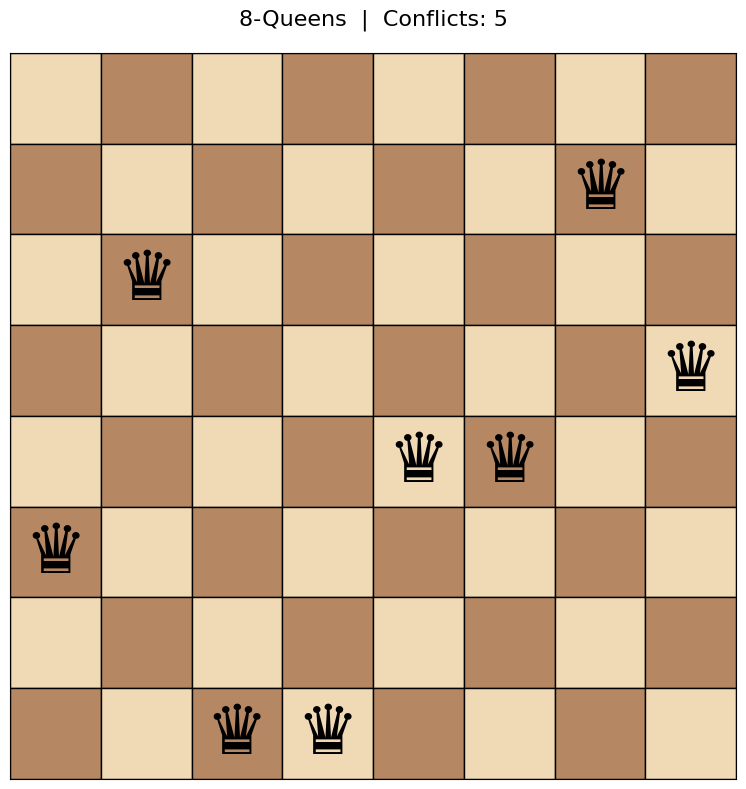

final state:


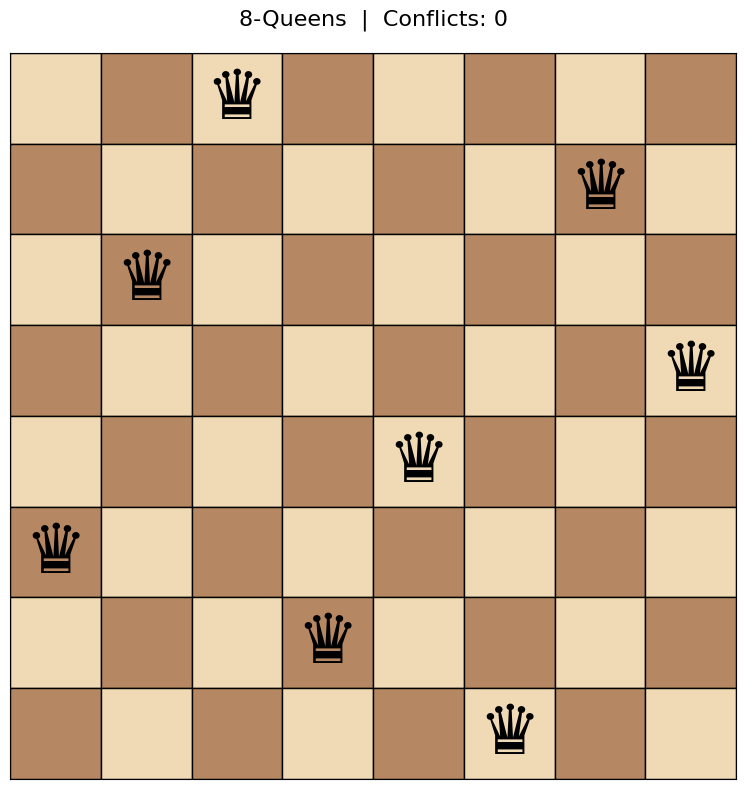

solution:


In [12]:
def beam_search(initial_state: NQueensState, beam_width: int = 10, max_iterations: int = 1000) -> Tuple[NQueensState, List[NQueensState]]:
	"""
	Beam Search algorithm.
	Keeps track of the best 'beam_width' states at each step.
	Generates all neighbors, sorts them, and keeps the top ones.
	"""
	# initialize beam and path
	beam = [initial_state.copy()]
	path = [beam[0]]
	# loop until max_iterations
		# if the best state in beam is goal, return it
		# generate all neighbors from all states in beam
		# sort candidates by conflicts and keep top beam_width
		# add best state to path
	for _ in range(max_iterations):
		best = min(beam, key=lambda s: s.calculate_conflicts())
		if best.is_goal():
			path.append(best)
			return best, path
		candidates = []
		for state in beam:
			candidates.extend(state.generate_neighbors())

		candidates.sort(key=lambda s: s.calculate_conflicts())
		beam = candidates[:beam_width]

		path.append(beam[0])
	# return best state and path
	best = min(beam, key=lambda s: s.calculate_conflicts())
	return best, path


# Test
n = 8
initial = NQueensState(n)
solution, path = beam_search(initial)

print(f"Initial conflicts: {path[0].calculate_conflicts()}")
print(f"Final conflicts: {solution.calculate_conflicts()}")
print(f"Is solution? {solution.is_goal()}")
print(f"Steps: {len(path)}")

# Show initial state
print("initial state:")
visualize_board(path[0])

# Show final state
print("final state:")
visualize_board(solution)

# Show the animation
print("solution:")
show_solution_animation(path)

#### 5.2- BS success probability (5 points)

- Find the probability for 8 queens.
- Find the probability for 16 queens.
- Find the mean execution time for each.
- Find the mean path length.

It may take a long time. (e.g. 10 min)

In [13]:
def evaluate_beam_search(n: int, trials: int = 50, max_iterations: int = 1000) -> tuple:
	"""
	Evaluate Beam Search using Monte Carlo simulation.
	Returns success rate, mean execution time, and mean path length.
	"""
	# initialize counters for successes, total_time, total_path_length
	successes = 0
	total_time = 0.0
	total_path_length = 0
	# loop for the number of trials
		# measure time and run beam search
		# update counters
	for _ in range(trials):
		initial_state = NQueensState(n)
		start_time = time.time()
		solution, path = beam_search(initial_state)
		end_time = time.time()
		if solution.is_goal():
			successes += 1
		total_time += end_time - start_time
		total_path_length += len(path)
	# calculate and return averages
	return successes/trials, total_time/trials, total_path_length/trials


prob_8, time_8, path_8 = evaluate_beam_search(8)
print(f"8 Queens  -> Success: {prob_8:.2%}, Mean Time: {time_8*1000:.6f}ms, Mean Path: {path_8:.1f}")

prob_16, time_16, path_16 = evaluate_beam_search(16)
print(f"16 Queens -> Success: {prob_16:.2%}, Mean Time: {time_16*1000:.6f}ms, Mean Path: {path_16:.1f}")

8 Queens  -> Success: 80.00%, Mean Time: 476.943731ms, Mean Path: 205.5
16 Queens -> Success: 70.00%, Mean Time: 11067.081256ms, Mean Path: 308.6


### Explain you results. (5 points)

Beam search does pretty well: 80% success on 8‑queens and 70% on 16‑queens, which is much better than simple hill climbing and even beats simulated annealing on the larger board. But it's slow. On 8‑queens it takes 477 ms and 206 moves; on 16‑queens it jumps to over 11 seconds and 309 moves. For a beam of width 10, each iteration generates beam_width × n × (n‑1) neighbors—that's 720 for 8‑queens and 2400 for 16‑queens. Evaluating each candidate requires O(n²) conflict checks, so the work per step grows fast. Beyond that, the larger board has way more local optima, and a fixed beam width can lose diversity early, making the algorithm get stuck even after hundreds of moves. That's why 30% of the 16‑queens trials still fail despite the long runtime. So beam search is reliable, but you pay a heavy price in time and path length, and even then it doesn't always find a solution on bigger boards.

## Conclusion (10 points)
Fill in the table below with your results, then explain what you observe.

<div align="center">

| Method                | Success (8) | Success (16) | Path Length (8) | Path Length (16) | Mean Time (8) | Mean Time (16) |
|-----------------------|------------|-------------|----------------|-----------------|--------------|----------------|
| Hill Climbing         | 17.0%      | 3.3%        | 4.3            | 7.7             | 1.13 ms      | 29.65 ms       |
| HC with Sideways      | 95.2%      | 97.8%       | 21.8           | 33.2            | 5.01 ms      | 109.94 ms      |
| Simulated Annealing   | 31.5%      | 0.5%        | 26.6           | 39.2            | 2.49 ms      | 9.75 ms        |
| Beam Search           | 80.0%      | 70.0%       | 205.5          | 308.6           | 476.94 ms    | 11067.08 ms    |
</div>

### Explain the results.

Simple hill climbing is very fast but succeeds only 17% of the time on 8‑queens and just 3.3% on 16‑queens, because it gets trapped in local optima. Adding sideways moves fixes this: success jumps to over 95% for both board sizes with only a small increase in time, proving that letting the algorithm wander across flat plateaus is a game changer. Simulated annealing with a cooling rate of 0.9 works decently on 8‑queens (31.5%) but collapses to 0.5% on 16‑queens—the temperature drops too fast to escape deeper local minima on larger boards. Beam search is the most reliable on 16‑queens (70% success) and also strong on 8‑queens (80%), but it's brutally slow: over 11 seconds for 16‑queens and path lengths exceeding 300 moves, because each step evaluates thousands of candidates. Overall, sideways‑move hill climbing offers the best balance of speed and reliability for this problem, while SA and beam search would need careful parameter tuning to scale well.